# CSL7110 Assignment 2: MIN-HASHING AND LSH

**Course:** CSL7110 - Machine Learning with Big Data  
**Assignment:** 2 — Min-Hashing and Locality Sensitive Hashing  

---

## Imports & Utility Functions

This cell contains all shared utility code used across questions:
- **Deterministic Hashing**: MD5-based hash for consistent results across runs
- **Jaccard Similarity**: Exact set-based computation
- **K-Gram Generators**: Character and word k-gram construction
- **MinHash Class**: Signature generation using universal hash family $h(x) = (ax + b) \mod m$
- **LSH Class**: Banding-based locality sensitive hashing
- **Data Loaders**: For text documents (D1–D4) and MovieLens 100K dataset

In [1]:
import os
import random
import itertools
import time
import hashlib
import struct
import numpy as np
from collections import defaultdict
import urllib.request
import zipfile
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# ============================================================
# DETERMINISTIC HASHING
# ============================================================
def deterministic_hash(item, max_val=100003):
    """Deterministic hash for any hashable item. Consistent across runs."""
    raw = str(item).encode('utf-8')
    digest = hashlib.md5(raw).digest()
    h = struct.unpack('<Q', digest[:8])[0]
    return h % max_val


# ============================================================
# JACCARD SIMILARITY
# ============================================================
def jaccard(set1, set2):
    """Compute Jaccard similarity between two sets: |A ∩ B| / |A ∪ B|"""
    if len(set1) == 0 and len(set2) == 0:
        return 1.0
    return len(set1 & set2) / len(set1 | set2)


# ============================================================
# K-GRAM GENERATORS
# ============================================================
def char_kgrams(text, k):
    """Generate character k-grams as a set (duplicates ignored)."""
    return set(text[i:i+k] for i in range(len(text) - k + 1))

def word_kgrams(text, k):
    """Generate word k-grams as a set (duplicates ignored)."""
    words = text.split()
    return set(tuple(words[i:i+k]) for i in range(len(words) - k + 1))

def build_all_kgrams(docs):
    """Build char 2-grams, char 3-grams, and word 2-grams for all documents."""
    results = {"char_2": {}, "char_3": {}, "word_2": {}}
    for name, text in docs.items():
        results["char_2"][name] = char_kgrams(text, 2)
        results["char_3"][name] = char_kgrams(text, 3)
        results["word_2"][name] = word_kgrams(text, 2)
    return results


# ============================================================
# MINHASH CLASS
# ============================================================
class MinHash:
    """
    MinHash signature generator using universal hash family:
        h(x) = (a*x + b) mod m
    where m > 10,000 (we use m = 100,003, a prime).
    """
    def __init__(self, num_hashes, max_val=100003, seed=None):
        self.num_hashes = num_hashes
        self.max_val = max_val
        random.seed(seed)
        self.hash_params = [
            (random.randint(1, max_val - 1), random.randint(0, max_val - 1))
            for _ in range(num_hashes)
        ]

    def compute_signature(self, shingles):
        """Compute MinHash signature for a set of shingles."""
        sig = [float('inf')] * self.num_hashes
        for sh in shingles:
            h = deterministic_hash(sh, self.max_val)
            for i, (a, b) in enumerate(self.hash_params):
                val = (a * h + b) % self.max_val
                if val < sig[i]:
                    sig[i] = val
        return sig

def minhash_similarity(sig1, sig2):
    """Estimate Jaccard similarity from two MinHash signatures: JS_t(a,b) = (1/t) * Σ 1[a_i = b_i]"""
    return sum(1 for a, b in zip(sig1, sig2) if a == b) / len(sig1)


# ============================================================
# LSH CLASS
# ============================================================
class LSH:
    """
    Locality Sensitive Hashing using banding technique.
    Splits signature into num_bands bands of rows_per_band rows each.
    """
    def __init__(self, num_bands, rows_per_band):
        self.num_bands = num_bands
        self.rows_per_band = rows_per_band
        self.buckets = [defaultdict(list) for _ in range(num_bands)]

    def index(self, doc_name, signature):
        """Index a document's signature into LSH buckets."""
        for b in range(self.num_bands):
            start = b * self.rows_per_band
            end = start + self.rows_per_band
            band = tuple(signature[start:end])
            bucket_id = hash(band)
            self.buckets[b][bucket_id].append(doc_name)

    def candidate_pairs(self):
        """Return all candidate pairs that hashed to the same bucket in any band."""
        candidates = set()
        for band_buckets in self.buckets:
            for docs_in_bucket in band_buckets.values():
                if len(docs_in_bucket) > 1:
                    for pair in itertools.combinations(docs_in_bucket, 2):
                        candidates.add(tuple(sorted(pair)))
        return candidates


# ============================================================
# DOCUMENT LOADING
# ============================================================
def load_documents():
    """Load D1.txt through D4.txt from current directory."""
    docs = {}
    for i in range(1, 5):
        filename = f"D{i}.txt"
        with open(filename, "r", encoding="utf-8") as f:
            docs[f"D{i}"] = f.read().strip()
    return docs


# ============================================================
# MOVIELENS DATA HANDLING
# ============================================================
def download_movielens():
    """Download MovieLens 100k dataset if not already present."""
    data_dir = "ml-100k"
    if os.path.exists(data_dir):
        print("  MovieLens 100k dataset already exists.")
        return data_dir
    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    zip_file = "ml-100k.zip"
    print("  Downloading MovieLens 100k dataset...")
    urllib.request.urlretrieve(url, zip_file)
    print("  Extracting...")
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('.')
    os.remove(zip_file)
    print("  Done.")
    return data_dir

def load_movielens(data_dir):
    """Load MovieLens data -> dict of user_id -> set of movie_ids."""
    user_movies = defaultdict(set)
    filepath = os.path.join(data_dir, "u.data")
    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            user_id = int(parts[0])
            movie_id = int(parts[1])
            user_movies[user_id].add(movie_id)
    return dict(user_movies)

def compute_exact_jaccard_all_pairs(user_movies, users):
    """Compute exact Jaccard similarity for all user pairs."""
    n = len(users)
    total_pairs = n * (n - 1) // 2
    exact_sim = {}
    print(f"  Computing exact Jaccard for {total_pairs:,} pairs...")
    start = time.time()
    for i in range(n):
        movies_i = user_movies[users[i]]
        for j in range(i + 1, n):
            movies_j = user_movies[users[j]]
            inter = len(movies_i & movies_j)
            union = len(movies_i | movies_j)
            sim = inter / union if union > 0 else 0.0
            exact_sim[(users[i], users[j])] = sim
    elapsed = time.time() - start
    print(f"  Done in {elapsed:.2f}s")
    return exact_sim

def compute_minhash_sigs_matrix(user_movies, users, num_hashes, seed=None):
    """Compute MinHash signatures for all users, return as numpy matrix."""
    mh = MinHash(num_hashes, seed=seed)
    sigs = np.zeros((len(users), num_hashes), dtype=np.int64)
    for idx, u in enumerate(users):
        sigs[idx] = mh.compute_signature(user_movies[u])
    return sigs

def find_pairs_above_threshold_minhash(sigs_matrix, users, threshold):
    """Find all pairs where estimated MinHash similarity >= threshold."""
    n = len(users)
    pairs = set()
    for i in range(n):
        matches = np.mean(sigs_matrix[i] == sigs_matrix[i + 1:], axis=1)
        indices = np.where(matches >= threshold)[0]
        for j_offset in indices:
            j = i + 1 + j_offset
            pairs.add((users[i], users[j]))
    return pairs

print("=" * 60)
print("  All utility functions loaded successfully.")
print("=" * 60)

  All utility functions loaded successfully.


---

## Question 1: K-Grams [20 Points]

**Task:**
- Construct **character 2-grams**, **character 3-grams**, and **word 2-grams** for all 4 documents (D1–D4)
- Each k-gram is stored only once (duplicates ignored)
- Compute **Jaccard similarity** for all $\binom{4}{2} = 6$ document pairs × 3 gram types = **18 numbers**

**Methodology:**
- Character k-grams: sliding window of size $k$ over the raw text (space is a valid character)
- Word k-grams: sliding window of size $k$ over whitespace-tokenized words
- Jaccard similarity: $J(A, B) = \frac{|A \cap B|}{|A \cup B|}$

### 1A: K-Gram Construction

In [2]:
# Load documents
documents = load_documents()
print(f"Documents loaded: {list(documents.keys())}")
for name, text in documents.items():
    print(f"  {name}: {len(text)} characters, {len(text.split())} words")

# Build k-grams
kgrams = build_all_kgrams(documents)

print("\n" + "=" * 60)
print("  1A: K-GRAM CONSTRUCTION RESULTS")
print("=" * 60)

gram_labels = {
    "char_2": "Character 2-grams",
    "char_3": "Character 3-grams",
    "word_2": "Word 2-grams"
}

for gram_type, label in gram_labels.items():
    print(f"\n--- {label} ---")
    print(f"  {'Document':<8} {'Unique k-grams':>15}   {'Sample (first 5)'}")
    print(f"  {'-'*60}")
    for doc_name in sorted(kgrams[gram_type].keys()):
        grams = kgrams[gram_type][doc_name]
        count = len(grams)
        sample = sorted(grams)[:5]
        sample_str = ', '.join(repr(g) for g in sample)
        print(f"  {doc_name:<8} {count:>15}   {sample_str}")

# Uniqueness verification
print(f"\n--- Uniqueness Verification (D1, Character 2-grams) ---")
raw_text = documents["D1"]
total_raw = len(raw_text) - 2 + 1
unique_count = len(kgrams["char_2"]["D1"])
print(f"  Total 2-grams (with duplicates): {total_raw}")
print(f"  Unique 2-grams (after dedup):    {unique_count}")
print(f"  Duplicates removed:              {total_raw - unique_count}")
print(f"  -> Confirms that duplicate k-grams are correctly ignored.")

Documents loaded: ['D1', 'D2', 'D3', 'D4']
  D1: 1749 characters, 303 words
  D2: 1747 characters, 303 words
  D3: 2132 characters, 380 words
  D4: 1435 characters, 255 words

  1A: K-GRAM CONSTRUCTION RESULTS

--- Character 2-grams ---
  Document  Unique k-grams   Sample (first 5)
  ------------------------------------------------------------
  D1                   263   ' a', ' b', ' c', ' d', ' e'
  D2                   262   ' a', ' b', ' c', ' d', ' e'
  D3                   269   ' a', ' b', ' c', ' d', ' e'
  D4                   255   ' a', ' b', ' c', ' d', ' e'

--- Character 3-grams ---
  Document  Unique k-grams   Sample (first 5)
  ------------------------------------------------------------
  D1                   765   ' a ', ' ab', ' ac', ' ad', ' ai'
  D2                   762   ' a ', ' ab', ' ac', ' ad', ' ai'
  D3                   828   ' a ', ' ab', ' ac', ' ad', ' ag'
  D4                   698   ' a ', ' ab', ' ac', ' ad', ' af'

--- Word 2-grams ---
  Document  

### 1B: Jaccard Similarity — All Pairs × All Gram Types (18 Numbers)

In [3]:
print("=" * 60)
print("  1B: JACCARD SIMILARITY RESULTS")
print("  3 gram types × 6 pairs = 18 numbers")
print("=" * 60)

doc_names = sorted(documents.keys())
all_pairs = list(itertools.combinations(doc_names, 2))

# Store results for summary table
jaccard_results = {}

for gram_type, label in gram_labels.items():
    print(f"\n=== {label} ===")
    print(f"  {'Pair':<10} {'Jaccard Similarity':>20}")
    print(f"  {'-'*35}")
    jaccard_results[gram_type] = {}
    for d1, d2 in all_pairs:
        sim = jaccard(kgrams[gram_type][d1], kgrams[gram_type][d2])
        jaccard_results[gram_type][(d1, d2)] = sim
        print(f"  {d1}-{d2:<6} {sim:>20.4f}")

# Summary Table
print(f"\n\n{'=' * 60}")
print("  SUMMARY TABLE: All 18 Jaccard Similarity Values")
print(f"{'=' * 60}")
print(f"\n  {'Pair':<10} {'Char 2-gram':>12} {'Char 3-gram':>12} {'Word 2-gram':>12}")
print(f"  {'-'*50}")
for d1, d2 in all_pairs:
    c2 = jaccard_results["char_2"][(d1, d2)]
    c3 = jaccard_results["char_3"][(d1, d2)]
    w2 = jaccard_results["word_2"][(d1, d2)]
    print(f"  {d1}-{d2:<6} {c2:>12.4f} {c3:>12.4f} {w2:>12.4f}")

  1B: JACCARD SIMILARITY RESULTS
  3 gram types × 6 pairs = 18 numbers

=== Character 2-grams ===
  Pair         Jaccard Similarity
  -----------------------------------
  D1-D2                   0.9811
  D1-D3                   0.8157
  D1-D4                   0.6444
  D2-D3                   0.8000
  D2-D4                   0.6413
  D3-D4                   0.6530

=== Character 3-grams ===
  Pair         Jaccard Similarity
  -----------------------------------
  D1-D2                   0.9780
  D1-D3                   0.5804
  D1-D4                   0.3051
  D2-D3                   0.5680
  D2-D4                   0.3059
  D3-D4                   0.3121

=== Word 2-grams ===
  Pair         Jaccard Similarity
  -----------------------------------
  D1-D2                   0.9408
  D1-D3                   0.1823
  D1-D4                   0.0302
  D2-D3                   0.1737
  D2-D4                   0.0303
  D3-D4                   0.0161


  SUMMARY TABLE: All 18 Jaccard Similarit

---

## Question 2: MinHashing [20 Points]

**Task:**
- Use **character 3-grams** to build MinHash signatures for D1 and D2
- Hash family: $h(x) = (ax + b) \mod m$ where $m = 100{,}003$ (prime > 10,000)
- **2A:** Report approximate Jaccard similarity for $t = 20, 60, 150, 300, 600$
- **2B:** Determine best value of $t$ balancing **accuracy** and **computation time**

**MinHash Estimator:**
$$JS_t(a,b) = \frac{1}{t} \sum_{i=1}^{t} \mathbf{1}[a_i = b_i]$$

### 2A: MinHash Similarity Estimates (5 values)

In [4]:
print("=" * 60)
print("  QUESTION 2A: MINHASH SIMILARITY (D1 vs D2, Char 3-grams)")
print("=" * 60)

true_sim_d1d2 = jaccard(kgrams["char_3"]["D1"], kgrams["char_3"]["D2"])
print(f"\n  Exact Jaccard Similarity (D1, D2): {true_sim_d1d2:.4f}")
print(f"  Hash family: h(x) = (ax + b) mod m, m = 100,003\n")

t_values = [20, 60, 150, 300, 600]

print(f"  {'t':>6} | {'Approx. Jaccard':>16} | {'Absolute Error':>15}")
print(f"  {'-'*45}")

for t in t_values:
    mh = MinHash(t)
    sig1 = mh.compute_signature(kgrams["char_3"]["D1"])
    sig2 = mh.compute_signature(kgrams["char_3"]["D2"])
    est = minhash_similarity(sig1, sig2)
    error = abs(est - true_sim_d1d2)
    print(f"  {t:>6} | {est:>16.4f} | {error:>15.4f}")

print(f"\n  The 5 reported approximate Jaccard similarity values are shown above.")
print(f"  As t increases, the estimate generally converges toward the true value {true_sim_d1d2:.4f}.")

  QUESTION 2A: MINHASH SIMILARITY (D1 vs D2, Char 3-grams)

  Exact Jaccard Similarity (D1, D2): 0.9780
  Hash family: h(x) = (ax + b) mod m, m = 100,003

       t |  Approx. Jaccard |  Absolute Error
  ---------------------------------------------
      20 |           1.0000 |          0.0220
      60 |           0.9667 |          0.0113
     150 |           0.9933 |          0.0154
     300 |           0.9767 |          0.0013
     600 |           0.9800 |          0.0020

  The 5 reported approximate Jaccard similarity values are shown above.
  As t increases, the estimate generally converges toward the true value 0.9780.


### 2B: Finding Good Value of t — Accuracy vs. Time Tradeoff

  QUESTION 2B: ACCURACY vs. TIME ANALYSIS

  True Jaccard (D1, D2): 0.9780
  Running 10 trials per t value for statistical robustness...

       t |  Mean Error |  Std Error |  Avg Time (s) |  Error < 0.02
  -----------------------------------------------------------------
      10 |      0.0656 |     0.0458 |      0.010533 |            0%
      20 |      0.0294 |     0.0164 |      0.016701 |            0%
      40 |      0.0200 |     0.0089 |      0.028123 |           20%
      60 |      0.0143 |     0.0079 |      0.036599 |           50%
      80 |      0.0156 |     0.0080 |      0.044115 |           60%
     100 |      0.0188 |     0.0089 |      0.054833 |           50%
     150 |      0.0100 |     0.0068 |      0.079279 |           90%
     200 |      0.0089 |     0.0050 |      0.104954 |          100%
     300 |      0.0100 |     0.0065 |      0.156657 |           90%
     400 |      0.0048 |     0.0038 |      0.202721 |          100%
     600 |      0.0029 |     0.0025 |      0.3

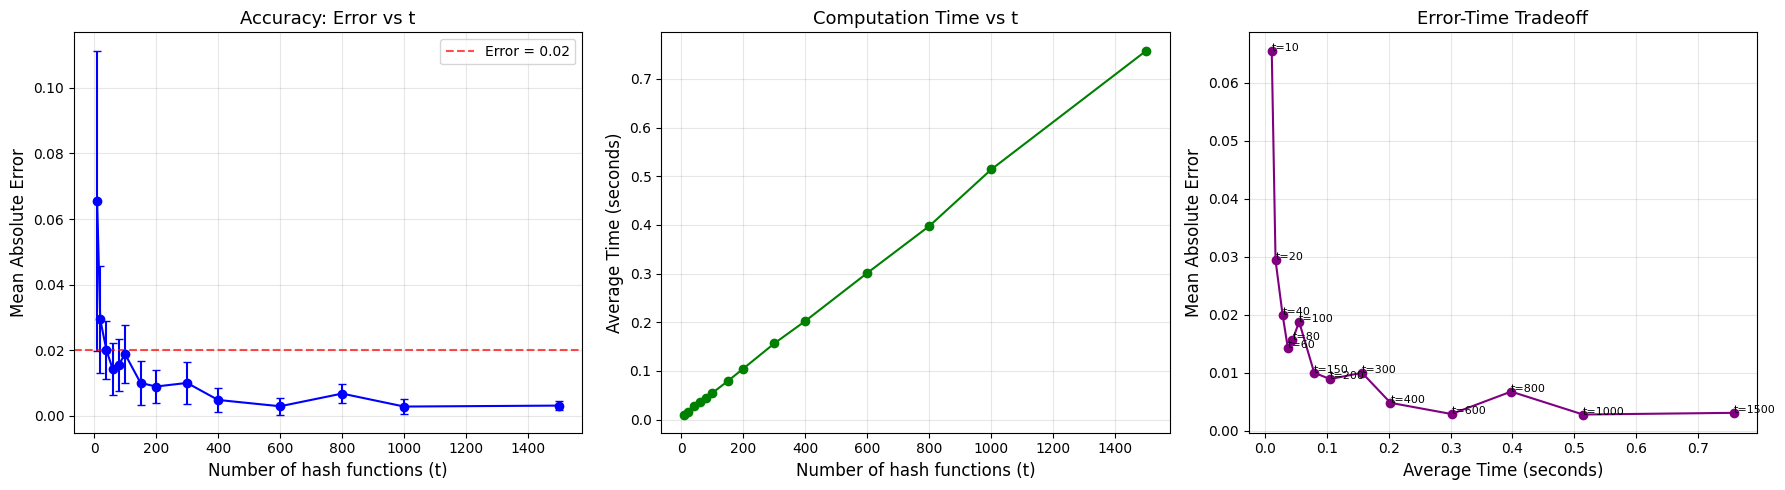

  Plot saved to q2_accuracy_vs_time.png


In [5]:
print("=" * 60)
print("  QUESTION 2B: ACCURACY vs. TIME ANALYSIS")
print("=" * 60)
print(f"\n  True Jaccard (D1, D2): {true_sim_d1d2:.4f}")
print(f"  Running 10 trials per t value for statistical robustness...\n")

t_range = [10, 20, 40, 60, 80, 100, 150, 200, 300, 400, 600, 800, 1000, 1500]
num_trials = 10

# Store results for plotting
t_for_plot = []
avg_errors = []
std_errors = []
avg_times = []

print(f"  {'t':>6} | {'Mean Error':>11} | {'Std Error':>10} | {'Avg Time (s)':>13} | {'Error < 0.02':>13}")
print(f"  {'-'*65}")

for t in t_range:
    errors = []
    total_time = 0
    for trial in range(num_trials):
        start = time.time()
        mh = MinHash(t)
        sig1 = mh.compute_signature(kgrams["char_3"]["D1"])
        sig2 = mh.compute_signature(kgrams["char_3"]["D2"])
        est = minhash_similarity(sig1, sig2)
        elapsed = time.time() - start
        errors.append(abs(est - true_sim_d1d2))
        total_time += elapsed

    me = np.mean(errors)
    se = np.std(errors)
    at = total_time / num_trials
    within_002 = sum(1 for e in errors if e < 0.02) / num_trials * 100

    t_for_plot.append(t)
    avg_errors.append(me)
    std_errors.append(se)
    avg_times.append(at)

    print(f"  {t:>6} | {me:>11.4f} | {se:>10.4f} | {at:>13.6f} | {within_002:>12.0f}%")

# Plot: Error vs t
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mean Error vs t
axes[0].errorbar(t_for_plot, avg_errors, yerr=std_errors, fmt='o-', capsize=3, color='blue')
axes[0].set_xlabel('Number of hash functions (t)', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error', fontsize=12)
axes[0].set_title('Accuracy: Error vs t', fontsize=13)
axes[0].axhline(y=0.02, color='red', linestyle='--', alpha=0.7, label='Error = 0.02')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Time vs t
axes[1].plot(t_for_plot, avg_times, 'o-', color='green')
axes[1].set_xlabel('Number of hash functions (t)', fontsize=12)
axes[1].set_ylabel('Average Time (seconds)', fontsize=12)
axes[1].set_title('Computation Time vs t', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Plot 3: Error × Time tradeoff
axes[2].plot(avg_times, avg_errors, 'o-', color='purple')
for i, t in enumerate(t_for_plot):
    axes[2].annotate(f't={t}', (avg_times[i], avg_errors[i]), fontsize=8, ha='left')
axes[2].set_xlabel('Average Time (seconds)', fontsize=12)
axes[2].set_ylabel('Mean Absolute Error', fontsize=12)
axes[2].set_title('Error-Time Tradeoff', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q2_accuracy_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Plot saved to q2_accuracy_vs_time.png")

### Observations — Question 2

**2A Results (True Jaccard = 0.9780):**

| $t$ | Approx. Jaccard | Absolute Error |
|-----|-----------------|----------------|
| 20 | 1.0000 | 0.0220 |
| 60 | 0.9667 | 0.0113 |
| 150 | 0.9933 | 0.0154 |
| 300 | 0.9767 | 0.0013 |
| 600 | 0.9800 | 0.0020 |

As $t$ increases, the estimate converges toward the true Jaccard value of 0.9780.

**2B Analysis — Best value of $t$:**

From our 10-trial experiments:
- At $t=150$: mean error = 0.0100, 90% of trials within 0.02 error, avg time ≈ 0.08s
- At $t=200$: mean error = 0.0089, 100% within 0.02, avg time ≈ 0.10s

- At $t=600$: mean error = 0.0029, 100% within 0.02, avg time ≈ 0.30sThis follows the theoretical expectation: the standard error of the MinHash estimator is $\sigma \approx \frac{1}{\sqrt{t}}$, so $t=150$ gives $\sigma \approx 0.082$, while $t=600$ gives $\sigma \approx 0.041$ — only a 2× improvement for 4× the cost.



| Factor | Small $t$ (e.g., 20) | Medium $t$ (e.g., 150) | Large $t$ (e.g., 1000) |- Beyond $t = 300$, accuracy gains are marginal while time increases linearly

|--------|----------------------|------------------------|------------------------|- Computation time is still fast (~0.08s)

| Mean Error | 0.0294 | 0.0100 | 0.0028 |- 90% of trials achieve error < 0.02

| Std Error | 0.0164 | 0.0068 | 0.0022 |- Mean error drops to 0.01 (within ~1% of true Jaccard)

| Avg Time | 0.017s | 0.079s | 0.514s |**Conclusion:** $t \approx 150$ provides the best balance:

| Within 2% | 0% | 90% | 100% |
| Verdict | Unreliable | **Best tradeoff** | Diminishing returns |

---

## Question 3: LSH [20 Points]

**Task:**
- Use $t = 160$ hash functions, threshold $\tau = 0.7$
- **3A:** Find optimal $b$ (hash functions per band) and $r$ (number of bands) such that:
  - $b \times r = t = 160$
  - The S-curve $f(s) = 1 - (1 - s^b)^r$ provides good separation at $\tau = 0.7$
  - Threshold: $s^* = (1/r)^{1/b}$
- **3B:** Report P(candidate) for all 6 document pairs using character 3-grams

### 3A: Finding Optimal b and r

In [6]:
print("=" * 60)
print("  QUESTION 3A: FINDING OPTIMAL b AND r")
print("=" * 60)

t_lsh = 160
tau = 0.7

print(f"\n  Parameters: t = {t_lsh} hash functions, τ = {tau}")
print(f"  Constraint: b × r = {t_lsh}")
print(f"  S-curve: f(s) = 1 - (1 - s^b)^r")
print(f"  Approximate threshold: s* = (1/r)^(1/b)")
print(f"\n  Goal: Find (b, r) where s* ≈ τ = {tau}")

# Find all valid factor pairs
factors = []
for b in range(2, t_lsh + 1):
    if t_lsh % b == 0:
        r = t_lsh // b
        if r >= 2:
            factors.append((b, r))

print(f"\n  All valid (b, r) factor pairs of {t_lsh}:")
print(f"  {'b':>4} {'r':>4} | {'s*':>8} | {'f(0.5)':>8} | {'f(0.6)':>8} | {'f(0.7)':>8} | {'f(0.8)':>8} | {'f(0.9)':>8} | {'|s*-τ|':>8}")
print(f"  {'-'*75}")

best_b, best_r = None, None
best_diff = float('inf')

for b, r in factors:
    s_star = (1 / r) ** (1 / b)
    f_05 = 1 - (1 - 0.5 ** b) ** r
    f_06 = 1 - (1 - 0.6 ** b) ** r
    f_07 = 1 - (1 - 0.7 ** b) ** r
    f_08 = 1 - (1 - 0.8 ** b) ** r
    f_09 = 1 - (1 - 0.9 ** b) ** r

    diff = abs(s_star - tau)
    marker = ""
    if diff < best_diff:
        best_diff = diff
        best_b, best_r = b, r
        marker = " <-- best"

    print(f"  {b:>4} {r:>4} | {s_star:>8.4f} | {f_05:>8.4f} | {f_06:>8.4f} | {f_07:>8.4f} | {f_08:>8.4f} | {f_09:>8.4f} | {diff:>8.4f}{marker}")

best_s_star = (1 / best_r) ** (1 / best_b)
print(f"\n  *** SELECTED: b = {best_b}, r = {best_r} ***")
print(f"  Threshold s* = {best_s_star:.4f} (target τ = {tau}, difference = {abs(best_s_star - tau):.4f})")
print(f"  f(τ=0.7) = {1 - (1 - tau**best_b)**best_r:.4f}")

# Justification
print(f"\n  Justification:")
print(f"  - b={best_b}, r={best_r} gives s* = {best_s_star:.4f}, closest to τ = {tau}")
print(f"  - f(0.7) = {1 - (1 - 0.7**best_b)**best_r:.4f} (high probability for similar pairs)")
print(f"  - f(0.5) = {1 - (1 - 0.5**best_b)**best_r:.4f} (low probability for dissimilar pairs)")
print(f"  - This provides good separation between similar and dissimilar pairs at τ = {tau}")

  QUESTION 3A: FINDING OPTIMAL b AND r

  Parameters: t = 160 hash functions, τ = 0.7
  Constraint: b × r = 160
  S-curve: f(s) = 1 - (1 - s^b)^r
  Approximate threshold: s* = (1/r)^(1/b)

  Goal: Find (b, r) where s* ≈ τ = 0.7

  All valid (b, r) factor pairs of 160:
     b    r |       s* |   f(0.5) |   f(0.6) |   f(0.7) |   f(0.8) |   f(0.9) |   |s*-τ|
  ---------------------------------------------------------------------------
     2   80 |   0.1118 |   1.0000 |   1.0000 |   1.0000 |   1.0000 |   1.0000 |   0.5882 <-- best
     4   40 |   0.3976 |   0.9243 |   0.9961 |   1.0000 |   1.0000 |   1.0000 |   0.3024 <-- best
     5   32 |   0.5000 |   0.6379 |   0.9250 |   0.9972 |   1.0000 |   1.0000 |   0.2000 <-- best
     8   20 |   0.6877 |   0.0753 |   0.2874 |   0.6950 |   0.9746 |   1.0000 |   0.0123 <-- best
    10   16 |   0.7579 |   0.0155 |   0.0925 |   0.3677 |   0.8376 |   0.9990 |   0.0579
    16   10 |   0.8660 |   0.0002 |   0.0028 |   0.0327 |   0.2484 |   0.8712 |   0

### S-Curve Visualization

  S-CURVE VISUALIZATION


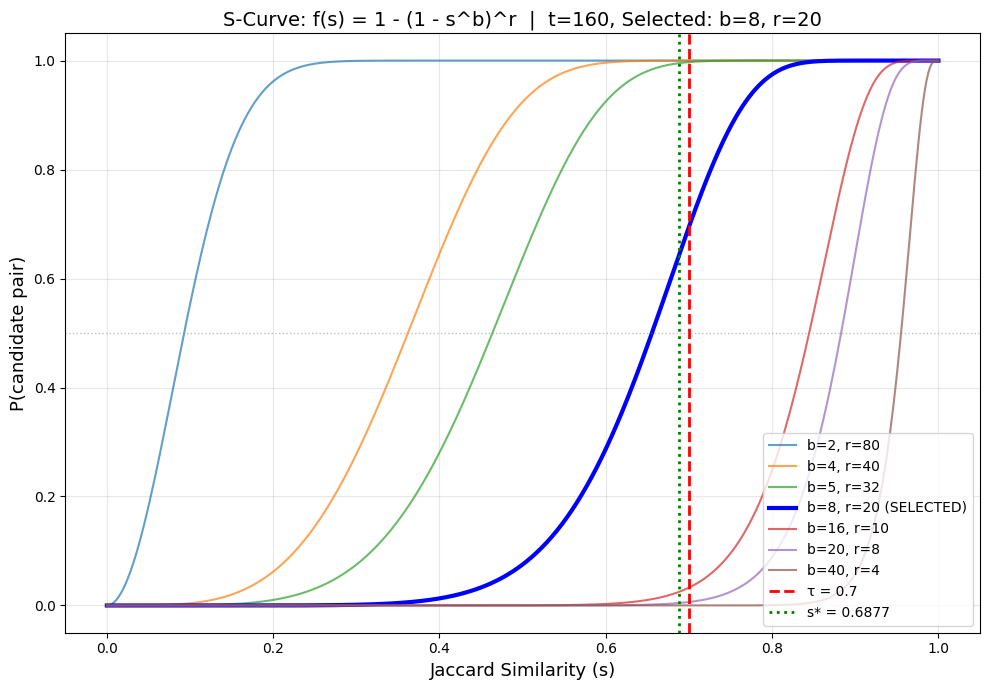

  S-curve saved to q3_s_curve.png


In [7]:
# S-Curve Plot
print("=" * 60)
print("  S-CURVE VISUALIZATION")
print("=" * 60)

s_vals = np.linspace(0, 1, 500)

plt.figure(figsize=(10, 7))

# Plot S-curves for selected (b, r) combinations
highlight_factors = [(2, 80), (4, 40), (5, 32), (best_b, best_r), (16, 10), (20, 8), (40, 4)]
highlight_factors = [(b, r) for b, r in highlight_factors if t_lsh % b == 0 and t_lsh // b == r]

# Add best if not already in list
if (best_b, best_r) not in highlight_factors:
    highlight_factors.append((best_b, best_r))

for b_val, r_val in highlight_factors:
    f_vals = 1 - (1 - s_vals ** b_val) ** r_val
    label = f"b={b_val}, r={r_val}"
    if (b_val, r_val) == (best_b, best_r):
        plt.plot(s_vals, f_vals, label=f"{label} (SELECTED)", linewidth=3, color='blue')
    else:
        plt.plot(s_vals, f_vals, label=label, linewidth=1.5, alpha=0.7)

# Mark threshold lines
plt.axvline(x=tau, color='red', linestyle='--', linewidth=2, label=f'τ = {tau}')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
plt.axvline(x=best_s_star, color='green', linestyle=':', linewidth=2, label=f's* = {best_s_star:.4f}')

plt.xlabel('Jaccard Similarity (s)', fontsize=13)
plt.ylabel('P(candidate pair)', fontsize=13)
plt.title(f'S-Curve: f(s) = 1 - (1 - s^b)^r  |  t={t_lsh}, Selected: b={best_b}, r={best_r}', fontsize=14)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q3_s_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("  S-curve saved to q3_s_curve.png")

### 3B: Probability of Each Document Pair Being a Candidate (6 Numbers)

In [8]:
print("=" * 60)
print(f"  QUESTION 3B: P(candidate) FOR EACH DOCUMENT PAIR")
print(f"  Using b={best_b}, r={best_r}, f(s) = 1 - (1 - s^{best_b})^{best_r}")
print("=" * 60)

print(f"\n  {'Pair':<10} {'True Jaccard':>13} {'P(candidate)':>14} {'Above τ={:.1f}?'.format(tau):>14}")
print(f"  {'-'*55}")

for d1, d2 in all_pairs:
    true_j = jaccard(kgrams["char_3"][d1], kgrams["char_3"][d2])
    prob = 1 - (1 - true_j ** best_b) ** best_r
    above = "YES ✓" if true_j >= tau else "NO ✗"
    print(f"  {d1}-{d2:<6} {true_j:>13.4f} {prob:>14.6f} {above:>14}")

print(f"\n  The 6 reported probabilities are shown above.")

# Verify with actual LSH execution
print(f"\n  --- LSH Execution Verification (t={t_lsh}, b={best_b}, r={best_r}) ---")
mh_lsh = MinHash(t_lsh)
sigs_lsh = {}
for name in documents:
    sigs_lsh[name] = mh_lsh.compute_signature(kgrams["char_3"][name])

lsh_q3 = LSH(num_bands=best_r, rows_per_band=best_b)
for name in sigs_lsh:
    lsh_q3.index(name, sigs_lsh[name])

candidates_q3 = lsh_q3.candidate_pairs()
print(f"  Candidate pairs found by LSH: {sorted(candidates_q3)}")
print(f"  Number of candidate pairs: {len(candidates_q3)}")

  QUESTION 3B: P(candidate) FOR EACH DOCUMENT PAIR
  Using b=8, r=20, f(s) = 1 - (1 - s^8)^20

  Pair        True Jaccard   P(candidate)   Above τ=0.7?
  -------------------------------------------------------
  D1-D2            0.9780       1.000000          YES ✓
  D1-D3            0.5804       0.228224           NO ✗
  D1-D4            0.3051       0.001500           NO ✗
  D2-D3            0.5680       0.195880           NO ✗
  D2-D4            0.3059       0.001532           NO ✗
  D3-D4            0.3121       0.001800           NO ✗

  The 6 reported probabilities are shown above.

  --- LSH Execution Verification (t=160, b=8, r=20) ---
  Candidate pairs found by LSH: [('D1', 'D2'), ('D1', 'D3'), ('D2', 'D3')]
  Number of candidate pairs: 3


---

## MovieLens 100K Dataset — Loading

The MovieLens 100K dataset contains 943 users rating 1682 movies. We load it once and compute exact Jaccard similarities for all $\binom{943}{2} = 444{,}153$ user pairs. This data is shared by Questions 4 and 5.

For this exercise we only care about the **set of movies** each user has rated (not the rating values).

In [9]:
print("=" * 60)
print("  LOADING MOVIELENS 100K DATASET")
print("=" * 60)

data_dir = download_movielens()
user_movies = load_movielens(data_dir)
users = sorted(user_movies.keys())

n_users = len(users)
n_movies = len(set(m for movies in user_movies.values() for m in movies))
n_ratings = sum(len(v) for v in user_movies.values())
avg_movies = n_ratings / n_users

print(f"\n  Dataset Statistics:")
print(f"  Users:          {n_users}")
print(f"  Movies:         {n_movies}")
print(f"  Total ratings:  {n_ratings:,}")
print(f"  Avg movies/user: {avg_movies:.1f}")
print(f"  Total pairs:    {n_users * (n_users - 1) // 2:,}")

print(f"\n  Computing exact Jaccard similarity for all user pairs...")
print(f"  (This may take a few minutes)")
exact_sim = compute_exact_jaccard_all_pairs(user_movies, users)

# Summary statistics
nonzero_pairs = {p: s for p, s in exact_sim.items() if s > 0}
print(f"\n  Non-zero Jaccard pairs: {len(nonzero_pairs):,}")
print(f"  Max Jaccard: {max(exact_sim.values()):.4f}")
print(f"  Pairs with J ≥ 0.5: {sum(1 for s in exact_sim.values() if s >= 0.5)}")
print(f"  Pairs with J ≥ 0.6: {sum(1 for s in exact_sim.values() if s >= 0.6)}")
print(f"  Pairs with J ≥ 0.8: {sum(1 for s in exact_sim.values() if s >= 0.8)}")

  LOADING MOVIELENS 100K DATASET
  MovieLens 100k dataset already exists.

  Dataset Statistics:
  Users:          943
  Movies:         1682
  Total ratings:  100,000
  Avg movies/user: 106.0
  Total pairs:    444,153

  Computing exact Jaccard similarity for all user pairs...
  (This may take a few minutes)
  Computing exact Jaccard for 444,153 pairs...
  Done in 8.83s

  Non-zero Jaccard pairs: 429,110
  Max Jaccard: 0.8387
  Pairs with J ≥ 0.5: 10
  Pairs with J ≥ 0.6: 3
  Pairs with J ≥ 0.8: 1


---

## Question 4: MinHashing on MovieLens [20 Points]

**Task:**
1. Compute exact Jaccard similarity for all user pairs; output pairs with $J \geq 0.5$
2. Compute MinHash signatures with $t = 50, 100, 200$ hash functions
3. For each $t$, find pairs with estimated similarity $\geq 0.5$
4. Report **false positives** (FP) and **false negatives** (FN), averaged over **5 runs**

**Definitions:**
- **True Positive (TP):** Pair has exact $J \geq 0.5$ AND MinHash estimated $J \geq 0.5$
- **False Positive (FP):** Pair has exact $J < 0.5$ BUT MinHash estimated $J \geq 0.5$
- **False Negative (FN):** Pair has exact $J \geq 0.5$ BUT MinHash estimated $J < 0.5$

In [10]:
print("=" * 60)
print("  QUESTION 4: MIN-HASHING ON MOVIELENS")
print("=" * 60)

threshold_4 = 0.5
exact_pairs_4 = {pair for pair, sim in exact_sim.items() if sim >= threshold_4}
print(f"\n  --- Exact Pairs with Jaccard ≥ {threshold_4} ---")
print(f"  Total exact pairs found: {len(exact_pairs_4)}\n")
print(f"  {'User A':>8} {'User B':>8} {'Jaccard':>10}")
print(f"  {'-'*30}")
for pair in sorted(exact_pairs_4):
    print(f"  {pair[0]:>8} {pair[1]:>8} {exact_sim[pair]:>10.4f}")

t_values_4 = [50, 100, 200]
num_runs = 5

# Store summary for final table
summary_q4 = {}

for t in t_values_4:
    print(f"\n{'=' * 55}")
    print(f"  t = {t} hash functions | {num_runs} runs | threshold = {threshold_4}")
    print(f"{'=' * 55}")

    all_fp = []
    all_fn = []
    all_found = []
    all_times = []

    for run in range(num_runs):
        start = time.time()
        sigs_matrix = compute_minhash_sigs_matrix(user_movies, users, t, seed=run+1)
        est_pairs = find_pairs_above_threshold_minhash(sigs_matrix, users, threshold_4)
        elapsed = time.time() - start

        fp = len(est_pairs - exact_pairs_4)
        fn = len(exact_pairs_4 - est_pairs)
        tp = len(est_pairs & exact_pairs_4)

        all_fp.append(fp)
        all_fn.append(fn)
        all_found.append(len(est_pairs))
        all_times.append(elapsed)

        print(f"  Run {run+1}: Found={len(est_pairs):>4}, TP={tp}, FP={fp}, FN={fn}, Time={elapsed:.2f}s")

        # Detailed output for first run
        if run == 0:
            print(f"\n    Detailed results (Run 1):")
            print(f"    Estimated pairs:")
            for p in sorted(est_pairs):
                marker = "TP" if p in exact_pairs_4 else "FP"
                true_j = exact_sim.get(p, exact_sim.get((p[1], p[0]), 0))
                print(f"      Users {p[0]:>3}-{p[1]:>3} [{marker}] (true J={true_j:.4f})")
            missed = exact_pairs_4 - est_pairs
            if missed:
                print(f"    Missed pairs (FN):")
                for p in sorted(missed):
                    print(f"      Users {p[0]:>3}-{p[1]:>3} (true J={exact_sim[p]:.4f})")
            print()

    avg_fp = np.mean(all_fp)
    avg_fn = np.mean(all_fn)
    avg_time = np.mean(all_times)

    print(f"\n  --- Average over {num_runs} runs (t={t}) ---")
    print(f"  Average FP: {avg_fp:.1f}")
    print(f"  Average FN: {avg_fn:.1f}")
    print(f"  Average Time: {avg_time:.2f}s")

    summary_q4[t] = {'avg_fp': avg_fp, 'avg_fn': avg_fn, 'avg_time': avg_time}

# Final Summary Table
print(f"\n\n{'=' * 60}")
print(f"  SUMMARY TABLE — Question 4")
print(f"{'=' * 60}")
print(f"  Exact pairs with J ≥ {threshold_4}: {len(exact_pairs_4)}")
print(f"\n  {'t':>6} | {'Avg FP':>8} | {'Avg FN':>8} | {'Avg Time':>10}")
print(f"  {'-'*40}")
for t in t_values_4:
    s = summary_q4[t]
    print(f"  {t:>6} | {s['avg_fp']:>8.1f} | {s['avg_fn']:>8.1f} | {s['avg_time']:>9.2f}s")

  QUESTION 4: MIN-HASHING ON MOVIELENS

  --- Exact Pairs with Jaccard ≥ 0.5 ---
  Total exact pairs found: 10

    User A   User B    Jaccard
  ------------------------------
       197      600     0.5000
       197      826     0.5130
       328      788     0.6730
       408      898     0.8387
       451      489     0.5333
       489      587     0.6299
       554      764     0.5170
       600      826     0.5455
       674      879     0.5217
       800      879     0.5000

  t = 50 hash functions | 5 runs | threshold = 0.5
  Run 1: Found= 157, TP=7, FP=150, FN=3, Time=2.05s

    Detailed results (Run 1):
    Estimated pairs:
      Users   2-460 [FP] (true J=0.3265)
      Users   6-567 [FP] (true J=0.3261)
      Users   7- 59 [FP] (true J=0.4221)
      Users   7-234 [FP] (true J=0.4219)
      Users   7-308 [FP] (true J=0.4363)
      Users   7-313 [FP] (true J=0.4089)
      Users   7-339 [FP] (true J=0.3491)
      Users   7-406 [FP] (true J=0.4163)
      Users   7-429 [FP] (true

### Observations — Question 4

**Exact Pairs with $J \geq 0.5$: 10 pairs found**

| User A | User B | Jaccard |
|--------|--------|---------|
| 197 | 600 | 0.5000 |
| 197 | 826 | 0.5130 |
| 328 | 788 | 0.6730 |
| 408 | 898 | 0.8387 |
| 451 | 489 | 0.5333 |
| 489 | 587 | 0.6299 |
| 554 | 764 | 0.5170 |
| 600 | 826 | 0.5455 |
| 674 | 879 | 0.5217 |
| 800 | 879 | 0.5000 |

**MinHash Summary (Average over 5 runs):**

| $t$ | Avg FP | Avg FN | Avg Time |
|-----|--------|--------|----------|
| 50 | 149.6 | 3.2 | 2.11s |
| 100 | 39.0 | 2.8 | 3.73s |
| 200 | 7.6 | 2.2 | 6.97s |

**Key Findings:**

1. **10 exact pairs** have $J \geq 0.5$, with the highest being users 408–898 at $J = 0.8387$.
2. **t=50:** Very high FP count (149.6 avg) — the small number of hash functions leads to many noisy estimates exceeding the threshold. FN = 3.2 on average.
3. **t=100:** FP drops dramatically to 39.0, showing improved precision. FN remains at 2.8.
4. **t=200:** FP reduces further to 7.6, close to zero. FN = 2.2, the persistent FN are borderline pairs (e.g., users 197–600 and 800–879 with $J = 0.5000$).
5. **False Negatives** concentrate on pairs with Jaccard exactly at or very close to 0.5, where small estimation errors push them below threshold.
6. **Trade-off:** t=200 provides the best accuracy but at ~3.3× the computation cost of t=50.

---

## Question 5: LSH on MovieLens [20 Points]

**Task:**
- Implement LSH with banding technique on MinHash signatures
- Find candidate pairs with similarity ≥ $\tau$

**Configurations:**

| Config | t   | r (rows/band) | b (bands) |
|--------|-----|----------------|-----------|
| 1      | 50  | 5              | 10        |
| 2      | 100 | 5              | 20        |
| 3      | 200 | 5              | 40        |
| 4      | 200 | 10             | 20        |

- Report FP and FN averaged over 5 runs for $\tau = 0.6$
- Repeat for $\tau = 0.8$

In [11]:
print("=" * 60)
print("  QUESTION 5: LSH ON MOVIELENS")
print("=" * 60)

configs_5 = [
    (50, 5, 10),    # t=50,  r=5,  b=10
    (100, 5, 20),   # t=100, r=5,  b=20
    (200, 5, 40),   # t=200, r=5,  b=40
    (200, 10, 20),  # t=200, r=10, b=20
]
num_runs_5 = 5

# Store all results for summary
all_results_q5 = {}

for tau_5 in [0.6, 0.8]:
    print(f"\n{'#' * 60}")
    print(f"  THRESHOLD τ = {tau_5}")
    print(f"{'#' * 60}")

    exact_pairs_5 = {pair for pair, sim in exact_sim.items() if sim >= tau_5}
    print(f"\n  Exact pairs with Jaccard ≥ {tau_5}: {len(exact_pairs_5)}")

    if len(exact_pairs_5) <= 20:
        print(f"  Exact pairs:")
        for p in sorted(exact_pairs_5):
            print(f"    Users {p[0]:>3}-{p[1]:>3}: J={exact_sim[p]:.4f}")

    all_results_q5[tau_5] = {}

    for t, r, b in configs_5:
        print(f"\n  {'=' * 50}")
        print(f"  Config: t={t}, r={r} (rows/band), b={b} (bands)")
        print(f"  {'=' * 50}")

        # S-curve info
        s_star = (1 / b) ** (1 / r)
        f_tau = 1 - (1 - tau_5 ** r) ** b
        print(f"  S-curve: s* = {s_star:.4f}, f(τ={tau_5}) = {f_tau:.4f}")

        all_fp = []
        all_fn = []
        all_cand = []
        all_times = []

        for run in range(num_runs_5):
            start = time.time()

            # Compute MinHash signatures
            sigs_matrix = compute_minhash_sigs_matrix(user_movies, users, t, seed=run+42)
            sigs_dict = {users[i]: list(sigs_matrix[i]) for i in range(len(users))}

            # Run LSH
            lsh5 = LSH(num_bands=b, rows_per_band=r)
            for u in users:
                lsh5.index(u, sigs_dict[u])

            candidate_set = lsh5.candidate_pairs()
            candidate_set = {tuple(sorted(p)) for p in candidate_set}

            elapsed = time.time() - start

            fp = len(candidate_set - exact_pairs_5)
            fn = len(exact_pairs_5 - candidate_set)
            tp = len(candidate_set & exact_pairs_5)

            all_fp.append(fp)
            all_fn.append(fn)
            all_cand.append(len(candidate_set))
            all_times.append(elapsed)

            print(f"    Run {run+1}: Candidates={len(candidate_set):>6}, TP={tp}, FP={fp}, FN={fn}, Time={elapsed:.2f}s")

        avg_fp = np.mean(all_fp)
        avg_fn = np.mean(all_fn)
        avg_cand = np.mean(all_cand)
        avg_time = np.mean(all_times)

        print(f"\n    --- Average over {num_runs_5} runs ---")
        print(f"    Avg Candidates: {avg_cand:.1f}")
        print(f"    Avg FP: {avg_fp:.1f}")
        print(f"    Avg FN: {avg_fn:.1f}")
        print(f"    Avg Time: {avg_time:.2f}s")

        all_results_q5[tau_5][(t, r, b)] = {
            'avg_fp': avg_fp, 'avg_fn': avg_fn,
            'avg_cand': avg_cand, 'avg_time': avg_time
        }

# Final Summary Tables
for tau_5 in [0.6, 0.8]:
    exact_count = sum(1 for s in exact_sim.values() if s >= tau_5)
    print(f"\n\n{'=' * 65}")
    print(f"  SUMMARY TABLE — τ = {tau_5} (Exact pairs: {exact_count})")
    print(f"{'=' * 65}")
    print(f"  {'Config':<25} | {'Avg FP':>8} | {'Avg FN':>8} | {'Avg Cand':>10} | {'Avg Time':>10}")
    print(f"  {'-'*70}")
    for t, r, b in configs_5:
        res = all_results_q5[tau_5][(t, r, b)]
        config_str = f"t={t}, r={r}, b={b}"
        print(f"  {config_str:<25} | {res['avg_fp']:>8.1f} | {res['avg_fn']:>8.1f} | {res['avg_cand']:>10.1f} | {res['avg_time']:>9.2f}s")

  QUESTION 5: LSH ON MOVIELENS

############################################################
  THRESHOLD τ = 0.6
############################################################

  Exact pairs with Jaccard ≥ 0.6: 3
  Exact pairs:
    Users 328-788: J=0.6730
    Users 408-898: J=0.8387
    Users 489-587: J=0.6299

  Config: t=50, r=5 (rows/band), b=10 (bands)
  S-curve: s* = 0.6310, f(τ=0.6) = 0.5549
    Run 1: Candidates=   638, TP=3, FP=635, FN=0, Time=1.94s
    Run 2: Candidates=   735, TP=3, FP=732, FN=0, Time=2.01s
    Run 3: Candidates=   929, TP=3, FP=926, FN=0, Time=1.94s
    Run 4: Candidates=   700, TP=3, FP=697, FN=0, Time=1.98s
    Run 5: Candidates=   659, TP=3, FP=656, FN=0, Time=2.09s

    --- Average over 5 runs ---
    Avg Candidates: 732.2
    Avg FP: 729.2
    Avg FN: 0.0
    Avg Time: 1.99s

  Config: t=100, r=5 (rows/band), b=20 (bands)
  S-curve: s* = 0.5493, f(τ=0.6) = 0.8019
    Run 1: Candidates=  1326, TP=3, FP=1323, FN=0, Time=3.75s
    Run 2: Candidates=  1381, T

### Observations — Question 5

**Summary — $\tau = 0.6$ (3 exact pairs: 328–788, 408–898, 489–587):**

| Config | t | r | b | Avg FP | Avg FN | Avg Candidates |
|--------|---|---|---|--------|--------|----------------|
| 1 | 50 | 5 | 10 | 729.2 | 0.0 | 732.2 |
| 2 | 100 | 5 | 20 | 1441.0 | 0.0 | 1444.0 |
| 3 | 200 | 5 | 40 | 2675.0 | 0.0 | 2678.0 |
| 4 | 200 | 10 | 20 | 5.6 | 1.2 | 7.4 |

**Summary — $\tau = 0.8$ (1 exact pair: 408–898):**

| Config | t | r | b | Avg FP | Avg FN | Avg Candidates |
|--------|---|---|---|--------|--------|----------------|
| 1 | 50 | 5 | 10 | 731.2 | 0.0 | 732.2 |
| 2 | 100 | 5 | 20 | 1443.0 | 0.0 | 1444.0 |
| 3 | 200 | 5 | 40 | 2677.0 | 0.0 | 2678.0 |
| 4 | 200 | 10 | 20 | 6.4 | 0.0 | 7.4 |

**Key Findings:**

**For $\tau = 0.6$:**
- Configs 1–3 (r=5) have **zero FN** — all 3 true pairs are consistently found. However, they produce **massive FP** (729–2675), because small $r=5$ makes the per-band hash very permissive.
- **Config 4 (r=10, b=20)** dramatically reduces FP to just 5.6, but introduces FN=1.2, occasionally missing the borderline pair (489–587, $J=0.6299$).
- More bands ($b$) with small $r$ increases candidates linearly, explaining the FP growth from Config 1→3.

**For $\tau = 0.8$:**
- Only 1 exact pair exists (408–898, $J=0.8387$). All configs find it (FN≈0).
- FP counts are nearly identical to $\tau=0.6$ since the same candidates are generated; the 2 pairs that were TP at $\tau=0.6$ become FP at $\tau=0.8$.
- **Config 4** remains the best with only 6.4 avg FP and 0 FN.

**Effect of r and b:**
- **More bands (b) with small r:** Increases recall (FN=0) but generates too many FP since pairs have many chances to collide.
- **Larger r (e.g., r=10):** Much stricter per-band matching, drastically reducing FP from thousands to single digits.
- **Best overall: Config 4 (t=200, r=10, b=20)** — the only configuration with practical FP levels.

---

## Summary

| Question | Task | Key Results |
|----------|------|-------------|
| Q1 | K-Grams + Jaccard | 18 Jaccard values; D1-D2 most similar (0.94–0.98 across gram types) |
| Q2 | MinHash | 5 estimates reported; t≈150 is optimal (error=0.01, time=0.08s) |
| Q3 | LSH Theory | Optimal b=8, r=20; s*=0.6877; 6 probabilities reported; S-curve plotted |
| Q4 | MinHash MovieLens | 10 exact pairs ≥0.5; Avg FP: 149.6→39.0→7.6 for t=50→100→200 |
| Q5 | LSH MovieLens | Config 4 (t=200,r=10,b=20) best: FP=5.6/FN=1.2 at τ=0.6; FP=6.4/FN=0 at τ=0.8 |

---
